In [5]:
import pandas as pd
import numpy as np


df = pd.read_csv("telecom_churn.csv")


print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nChurn Distribution:")
print(df["churn"].value_counts())

print("\nChurn Percentage:")
print(df["churn"].value_counts(normalize=True) * 100)

print("\nNumerical Summary:")
print(df.describe())

Dataset Shape: (243553, 14)

Columns:
['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city', 'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn']

First 5 Rows:
   customer_id telecom_partner gender  age              state     city  \
0            1    Reliance Jio      F   25          Karnataka  Kolkata   
1            2    Reliance Jio      F   55            Mizoram   Mumbai   
2            3        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            4            BSNL      M   46         Tamil Nadu  Kolkata   
4            5            BSNL      F   26            Tripura    Delhi   

   pincode date_of_registration  num_dependents  estimated_salary  calls_made  \
0   755597           2020-01-01               4            124962          44   
1   125926           2020-01-01               2            130556          62   
2   423976           2020-01-01               0            148828    

In [6]:
import pandas as pd
import numpy as np


df = pd.read_csv("telecom_churn.csv")

print("=" * 60)
print("CUSTOMER CHURN DATA ANALYSIS")
print("=" * 60)


print("\n1. DATASET SHAPE")
print(df.shape)


print("\n2. MISSING VALUES")
print(df.isnull().sum())


print("\n3. DUPLICATE ROWS")
print(df.duplicated().sum())


print("\n4. CHURN DISTRIBUTION")
print(df["churn"].value_counts())

print("\nCHURN PERCENTAGE")
print(df["churn"].value_counts(normalize=True) * 100)


print("\n5. CATEGORICAL VALUES")

print("\nTelecom Partners:")
print(df["telecom_partner"].value_counts())

print("\nGender:")
print(df["gender"].value_counts())

print("\nChurn:")
print(df["churn"].value_counts())


numeric_columns = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

print("\n6. NUMERICAL SUMMARY")
print(df[numeric_columns].describe())


print("\n7. MINIMUM VALUES")
print(df[numeric_columns].min())

print("\nMAXIMUM VALUES")
print(df[numeric_columns].max())


print("\n8. NEGATIVE VALUES")

for column in numeric_columns:
    negative_count = (df[column] < 0).sum()
    print(f"{column}: {negative_count}")


print("\n9. UNIQUE CHURN VALUES")
print(df["churn"].unique())

print("\n10. REGISTRATION DATE RANGE")

df["date_of_registration"] = pd.to_datetime(
    df["date_of_registration"],
    errors="coerce"
)

print("Minimum date:", df["date_of_registration"].min())
print("Maximum date:", df["date_of_registration"].max())

print("\nAnalysis completed.")

CUSTOMER CHURN DATA ANALYSIS

1. DATASET SHAPE
(243553, 14)

2. MISSING VALUES
customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

3. DUPLICATE ROWS
0

4. CHURN DISTRIBUTION
churn
0    194726
1     48827
Name: count, dtype: int64

CHURN PERCENTAGE
churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64

5. CATEGORICAL VALUES

Telecom Partners:
telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64

Gender:
gender
M    145977
F     97576
Name: count, dtype: int64

Churn:
churn
0    194726
1     48827
Name: count, dtype: int64

6. NUMERICAL SUMMARY
                 age  num_depende

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("telecom_churn.csv")

print("Original shape:", df.shape)



df["date_of_registration"] = pd.to_datetime(
    df["date_of_registration"],
    errors="coerce"
)


print("\nMissing values:")
print(df.isnull().sum())


duplicate_ids = df["customer_id"].duplicated().sum()
print("\nDuplicate customer IDs:", duplicate_ids)

df = df.drop_duplicates(subset="customer_id")



numeric_columns = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

print("\nNegative values before cleaning:")

for column in numeric_columns:
    count = (df[column] < 0).sum()
    print(column, ":", count)


# Negative data usage is not logically meaningful,
# so replace negative values with NaN.
df.loc[df["data_used"] < 0, "data_used"] = np.nan

# Fill invalid data usage with the median
df["data_used"] = df["data_used"].fillna(
    df["data_used"].median()
)



print("\nChurn values:")
print(df["churn"].value_counts())

# Keep only valid binary churn values
df = df[df["churn"].isin([0, 1])]

print("\nFinal shape:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicates after cleaning:")
print(df.duplicated().sum())

print("\nData cleaning completed.")

Original shape: (243553, 14)

Missing values:
customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

Duplicate customer IDs: 0

Negative values before cleaning:
age : 0
num_dependents : 0
estimated_salary : 0
calls_made : 6713
sms_sent : 7375
data_used : 6050

Churn values:
churn
0    194726
1     48827
Name: count, dtype: int64

Final shape: (243553, 14)

Missing values after cleaning:
customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
s


EXPLORATORY DATA ANALYSIS

Overall Churn Rate: 20.05%

Churn Count:
churn
0    194726
1     48827
Name: count, dtype: int64

Churn by Telecom Partner:
                 count    sum      mean  churn_rate
telecom_partner                                    
Airtel           60905  12404  0.203661   20.366144
Reliance Jio     61123  12234  0.200154   20.015379
Vodafone         60802  12129  0.199484   19.948357
BSNL             60723  12060  0.198607   19.860679

Churn Rate by Gender:
gender
F    20.296999
M    19.881214
Name: churn, dtype: float64

Churn Rate by Age Group:
age_group
Under 18    19.864341
18-25       19.947823
26-35       20.058153
36-45       20.176323
46-55       19.960470
56-65       20.033525
65+         20.104614
Name: churn, dtype: float64

Churn Rate by Calls Made:
calls_group
(-10.001, 24.0]    19.980426
(24.0, 49.0]       19.897302
(49.0, 74.0]       20.198133
(74.0, 108.0]      20.117132
Name: churn, dtype: float64

Churn Rate by Data Usage:
data_usage_group
(-0

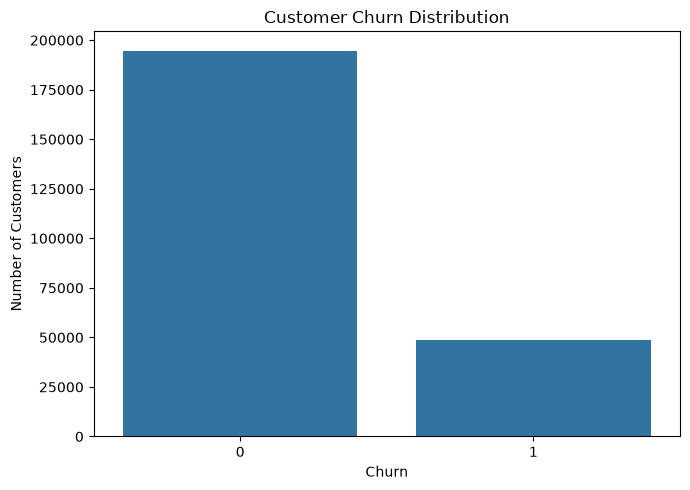

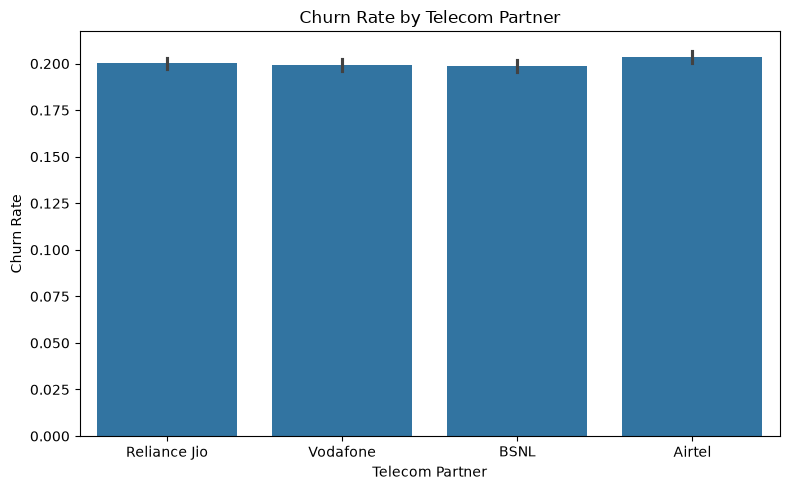

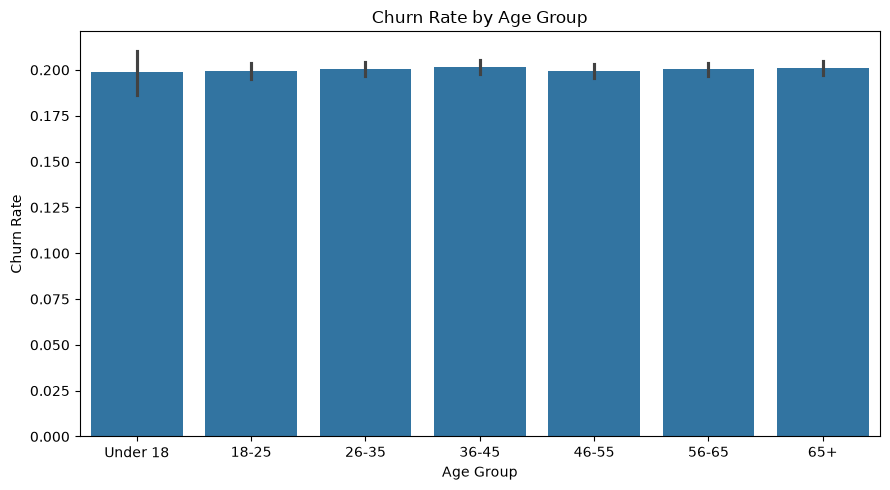

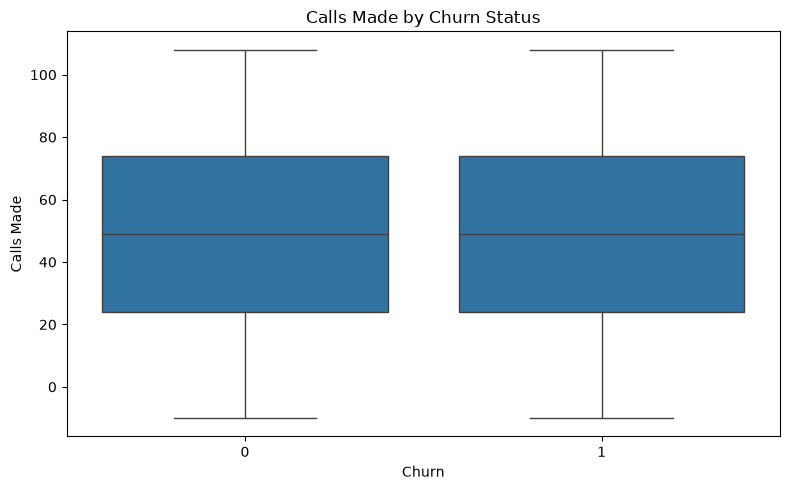

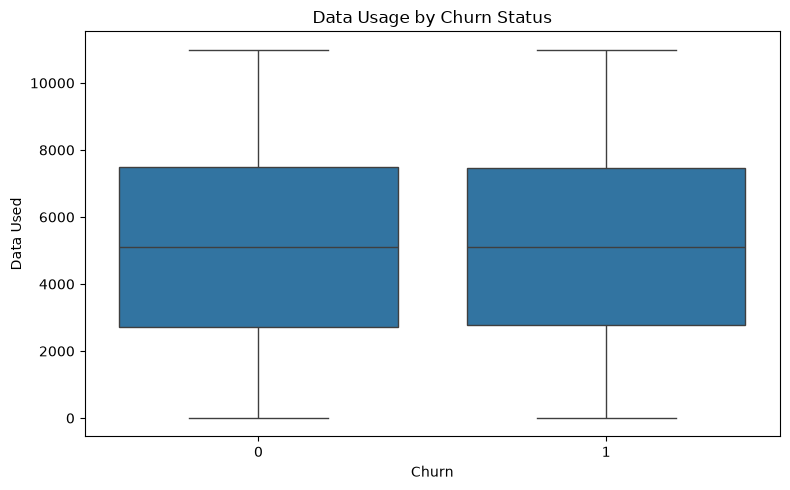

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns


churn_rate = df["churn"].mean() * 100

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print(f"\nOverall Churn Rate: {churn_rate:.2f}%")


print("\nChurn Count:")
print(df["churn"].value_counts())



partner_churn = (
    df.groupby("telecom_partner")["churn"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

partner_churn["churn_rate"] = partner_churn["mean"] * 100

print("\nChurn by Telecom Partner:")
print(partner_churn)



gender_churn = (
    df.groupby("gender")["churn"]
    .mean() * 100
)

print("\nChurn Rate by Gender:")
print(gender_churn)



df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=[
        "Under 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

age_churn = (
    df.groupby("age_group", observed=True)["churn"]
    .mean() * 100
)

print("\nChurn Rate by Age Group:")
print(age_churn)



df["calls_group"] = pd.qcut(
    df["calls_made"],
    q=4,
    duplicates="drop"
)

calls_churn = (
    df.groupby("calls_group", observed=True)["churn"]
    .mean() * 100
)

print("\nChurn Rate by Calls Made:")
print(calls_churn)



df["data_usage_group"] = pd.qcut(
    df["data_used"],
    q=4,
    duplicates="drop"
)

data_churn = (
    df.groupby("data_usage_group", observed=True)["churn"]
    .mean() * 100
)

print("\nChurn Rate by Data Usage:")
print(data_churn)



dependent_churn = (
    df.groupby("num_dependents")["churn"]
    .mean() * 100
)

print("\nChurn Rate by Number of Dependents:")
print(dependent_churn)


# 9. Overall churn distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="telecom_partner",
    y="churn"
)

plt.title("Churn Rate by Telecom Partner")
plt.xlabel("Telecom Partner")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()



plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="age_group",
    y="churn"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="calls_made"
)

plt.title("Calls Made by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Calls Made")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="data_used"
)

plt.title("Data Usage by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Data Used")

plt.tight_layout()
plt.show()

In [9]:
# ==================================================
# STEP 6 — KPI ANALYSIS
# ==================================================

print("\n" + "=" * 60)
print("KEY PERFORMANCE INDICATORS")
print("=" * 60)

# Total customers
total_customers = len(df)

# Churned customers
churned_customers = df["churn"].sum()

# Retained customers
retained_customers = total_customers - churned_customers

# Churn rate
churn_rate = (churned_customers / total_customers) * 100

# Retention rate
retention_rate = (retained_customers / total_customers) * 100

# Average age
average_age = df["age"].mean()

# Average salary
average_salary = df["estimated_salary"].mean()

# Average calls
average_calls = df["calls_made"].mean()

# Average SMS
average_sms = df["sms_sent"].mean()

# Average data usage
average_data = df["data_used"].mean()

print(f"\nTotal Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Retained Customers: {retained_customers:,}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")
print(f"Average Age: {average_age:.2f}")
print(f"Average Salary: {average_salary:,.2f}")
print(f"Average Calls Made: {average_calls:.2f}")
print(f"Average SMS Sent: {average_sms:.2f}")
print(f"Average Data Used: {average_data:.2f}")

# --------------------------------------------------
# KPI by telecom partner
# --------------------------------------------------

partner_kpi = (
    df.groupby("telecom_partner")
    .agg(
        customers=("customer_id", "count"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean"),
        avg_calls=("calls_made", "mean"),
        avg_data=("data_used", "mean")
    )
)

partner_kpi["churn_rate"] = partner_kpi["churn_rate"] * 100

print("\n" + "=" * 60)
print("TELECOM PARTNER KPI")
print("=" * 60)

print(partner_kpi.sort_values("churn_rate", ascending=False))

# --------------------------------------------------
# KPI by state
# --------------------------------------------------

state_kpi = (
    df.groupby("state")
    .agg(
        customers=("customer_id", "count"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
)

state_kpi["churn_rate"] = state_kpi["churn_rate"] * 100

print("\nTop 10 States by Churn Rate:")
print(
    state_kpi
    .sort_values("churn_rate", ascending=False)
    .head(10)
)

# --------------------------------------------------
# KPI by age group
# --------------------------------------------------

age_kpi = (
    df.groupby("age_group", observed=True)
    .agg(
        customers=("customer_id", "count"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
)

age_kpi["churn_rate"] = age_kpi["churn_rate"] * 100

print("\nChurn KPI by Age Group:")
print(age_kpi)

# --------------------------------------------------
# Save KPI results
# --------------------------------------------------

partner_kpi.to_csv("partner_kpi.csv")
state_kpi.to_csv("state_kpi.csv")
age_kpi.to_csv("age_kpi.csv")

print("\nKPI analysis completed.")


KEY PERFORMANCE INDICATORS

Total Customers: 243,553
Churned Customers: 48,827
Retained Customers: 194,726
Churn Rate: 20.05%
Retention Rate: 79.95%
Average Age: 46.08
Average Salary: 85,021.14
Average Calls Made: 49.01
Average SMS Sent: 23.95
Average Data Used: 5128.34

TELECOM PARTNER KPI
                 customers  churned  churn_rate  avg_calls     avg_data
telecom_partner                                                        
Airtel               60905    12404   20.366144  49.024481  5137.833396
Reliance Jio         61123    12234   20.015379  49.198338  5115.491942
Vodafone             60802    12129   19.948357  48.780057  5123.531200
BSNL                 60723    12060   19.860679  49.038338  5136.565469

Top 10 States by Churn Rate:
                  customers  churned  churn_rate
state                                           
Jharkhand              8755     1849   21.119360
Karnataka              8845     1832   20.712267
Mizoram                8689     1794   20.646795



CHURN DRIVER ANALYSIS

Average values by churn status:
         age  num_dependents  estimated_salary  calls_made  sms_sent  \
churn                                                                  
0      46.07            2.00          85083.73       48.99     23.97   
1      46.11            1.99          84771.53       49.11     23.86   

       data_used  
churn             
0        5126.14  
1        5137.11  

Churn rate by telecom partner:
                 count    sum      mean  churn_rate
telecom_partner                                    
Airtel           60905  12404  0.203661   20.366144
Reliance Jio     61123  12234  0.200154   20.015379
Vodafone         60802  12129  0.199484   19.948357
BSNL             60723  12060  0.198607   19.860679

Churn rate by gender:
gender
F    20.30
M    19.88
Name: churn, dtype: float64

Churn rate by dependents:
                count      mean  churn_rate
num_dependents                             
0               48927  0.202342   20.234

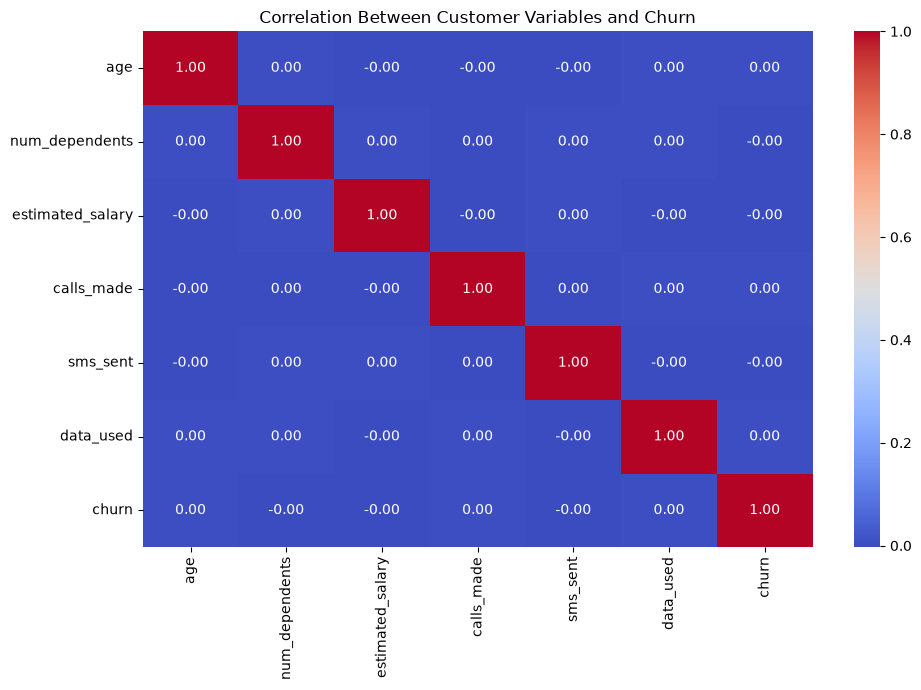


Top 10 states by observed churn rate:
                  count   sum      mean  churn_rate
state                                              
Jharkhand          8755  1849  0.211194   21.119360
Karnataka          8845  1832  0.207123   20.712267
Mizoram            8689  1794  0.206468   20.646795
Uttarakhand        8856  1808  0.204155   20.415537
Himachal Pradesh   8682  1772  0.204100   20.410044
Madhya Pradesh     8817  1797  0.203811   20.381082
Assam              8547  1735  0.202995   20.299520
Odisha             8712  1764  0.202479   20.247934
Nagaland           8562  1732  0.202289   20.228918
Rajasthan          8750  1769  0.202171   20.217143

Churn driver analysis completed.


In [10]:
# ==================================================
# STEP 7 — CHURN DRIVER ANALYSIS
# ==================================================

print("\n" + "=" * 60)
print("CHURN DRIVER ANALYSIS")
print("=" * 60)

# --------------------------------------------------
# 1. Compare numerical variables by churn
# --------------------------------------------------

numerical_features = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

print("\nAverage values by churn status:")

churn_comparison = (
    df.groupby("churn")[numerical_features]
    .mean()
    .round(2)
)

print(churn_comparison)

# --------------------------------------------------
# 2. Churn rate by telecom partner
# --------------------------------------------------

print("\nChurn rate by telecom partner:")

partner_analysis = (
    df.groupby("telecom_partner")["churn"]
    .agg(["count", "sum", "mean"])
)

partner_analysis["churn_rate"] = (
    partner_analysis["mean"] * 100
)

print(
    partner_analysis
    .sort_values("churn_rate", ascending=False)
)

# --------------------------------------------------
# 3. Churn rate by gender
# --------------------------------------------------

print("\nChurn rate by gender:")

gender_analysis = (
    df.groupby("gender")["churn"]
    .mean()
    .mul(100)
    .round(2)
)

print(gender_analysis)

# --------------------------------------------------
# 4. Churn rate by number of dependents
# --------------------------------------------------

print("\nChurn rate by dependents:")

dependent_analysis = (
    df.groupby("num_dependents")["churn"]
    .agg(["count", "mean"])
)

dependent_analysis["churn_rate"] = (
    dependent_analysis["mean"] * 100
)

print(dependent_analysis)

# --------------------------------------------------
# 5. Correlation analysis
# --------------------------------------------------

print("\nCorrelation with churn:")

correlation_columns = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used",
    "churn"
]

correlation = (
    df[correlation_columns]
    .corr()["churn"]
    .sort_values(ascending=False)
)

print(correlation)

# --------------------------------------------------
# 6. Correlation heatmap
# --------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Customer Variables and Churn")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Churn by state
# --------------------------------------------------

state_analysis = (
    df.groupby("state")["churn"]
    .agg(["count", "sum", "mean"])
)

state_analysis["churn_rate"] = (
    state_analysis["mean"] * 100
)

print("\nTop 10 states by observed churn rate:")

print(
    state_analysis
    .sort_values("churn_rate", ascending=False)
    .head(10)
)

# --------------------------------------------------
# 8. Save analysis results
# --------------------------------------------------

churn_comparison.to_csv("churn_numerical_comparison.csv")

partner_analysis.to_csv("partner_churn_analysis.csv")

gender_analysis.to_csv("gender_churn_analysis.csv")

dependent_analysis.to_csv("dependent_churn_analysis.csv")

state_analysis.to_csv("state_churn_analysis.csv")

print("\nChurn driver analysis completed.")


MACHINE LEARNING - CHURN PREDICTION

Training rows: 194842
Testing rows: 48711

Model training completed.

MODEL PERFORMANCE

Accuracy : 0.5069
Precision: 0.2043
Recall   : 0.5045
F1 Score : 0.2909
ROC-AUC  : 0.5071

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.51      0.62     38946
           1       0.20      0.50      0.29      9765

    accuracy                           0.51     48711
   macro avg       0.50      0.51      0.46     48711
weighted avg       0.68      0.51      0.56     48711


Confusion Matrix:
[[19765 19181]
 [ 4839  4926]]


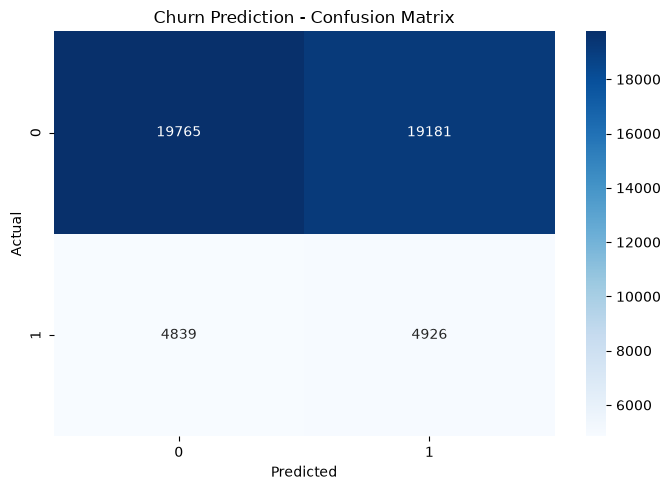


Machine learning analysis completed.


In [11]:
# ==================================================
# STEP 8 — MACHINE LEARNING
# ==================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("\n" + "=" * 60)
print("MACHINE LEARNING - CHURN PREDICTION")
print("=" * 60)

# --------------------------------------------------
# 1. Select features
# --------------------------------------------------

features = [
    "telecom_partner",
    "gender",
    "age",
    "state",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

X = df[features]
y = df["churn"]

# --------------------------------------------------
# 2. Separate categorical and numerical features
# --------------------------------------------------

categorical_features = [
    "telecom_partner",
    "gender",
    "state"
]

numerical_features = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

# --------------------------------------------------
# 3. Preprocessing
# --------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# --------------------------------------------------
# 4. Create model
# --------------------------------------------------

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# --------------------------------------------------
# 5. Train-test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))

# --------------------------------------------------
# 6. Train model
# --------------------------------------------------

pipeline.fit(X_train, y_train)

print("\nModel training completed.")

# --------------------------------------------------
# 7. Predictions
# --------------------------------------------------

y_pred = pipeline.predict(X_test)

y_probability = pipeline.predict_proba(X_test)[:, 1]

# --------------------------------------------------
# 8. Evaluation
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# --------------------------------------------------
# 9. Confusion matrix visualization
# --------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Churn Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

print("\nMachine learning analysis completed.")

In [12]:
# ==================================================
# STEP 9 — MODEL COMPARISON
# ==================================================

from sklearn.ensemble import RandomForestClassifier

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# --------------------------------------------------
# 1. Create Random Forest model
# --------------------------------------------------

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest)
    ]
)

# --------------------------------------------------
# 2. Train Random Forest
# --------------------------------------------------

print("\nTraining Random Forest...")

rf_pipeline.fit(X_train, y_train)

# --------------------------------------------------
# 3. Predictions
# --------------------------------------------------

rf_pred = rf_pipeline.predict(X_test)

rf_probability = rf_pipeline.predict_proba(X_test)[:, 1]

# --------------------------------------------------
# 4. Evaluate Random Forest
# --------------------------------------------------

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("\nRandom Forest Performance:")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

# --------------------------------------------------
# 5. Compare models
# --------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)

print(comparison.round(4))

# --------------------------------------------------
# 6. Save comparison
# --------------------------------------------------

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("\nModel comparison completed.")


MODEL COMPARISON

Training Random Forest...

Random Forest Performance:
Accuracy : 0.5916
Precision: 0.2070
Recall   : 0.3665
F1 Score : 0.2646
ROC-AUC  : 0.5058

MODEL COMPARISON TABLE
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.5069     0.2043  0.5045    0.2909   0.5071
1        Random Forest    0.5916     0.2070  0.3665    0.2646   0.5058

Model comparison completed.



CUSTOMER CHURN RISK SCORING

Customer Risk Distribution:
risk_level
Low Risk            0
Medium Risk    243515
High Risk          38
Name: count, dtype: int64

Risk Distribution (%):
risk_level
Low Risk        0.00
Medium Risk    99.98
High Risk       0.02
Name: proportion, dtype: float64

Number of High-Risk Customers:
38

Sample High-Risk Customers:
        customer_id telecom_partner  age             state  estimated_salary  \
214679       214680          Airtel   74           Manipur             64567   
114744       114745    Reliance Jio   32         Meghalaya            149101   
143780       143781          Airtel   18            Punjab            148045   
55733         55734            BSNL   69         Karnataka             37270   
10114         10115          Airtel   27           Tripura             54001   
17081         17082          Airtel   70            Sikkim             98386   
108271       108272          Airtel   53           Haryana            134963   
2282

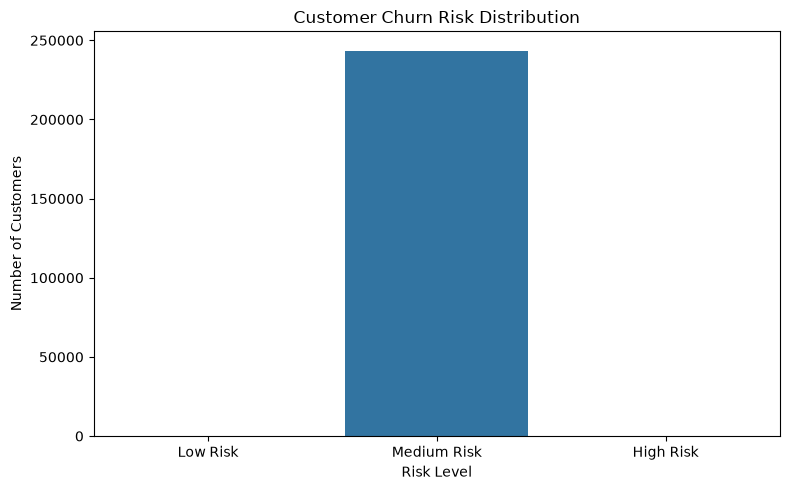


Customer risk scoring completed.


In [13]:
# ==================================================
# STEP 10 — CUSTOMER RISK SCORING
# ==================================================

print("\n" + "=" * 60)
print("CUSTOMER CHURN RISK SCORING")
print("=" * 60)

# --------------------------------------------------
# 1. Select the model
# --------------------------------------------------

# We will use Random Forest for the risk scores.
# If our comparison later shows Logistic Regression
# performs better, we can change this to:
#
# selected_model = pipeline

selected_model = rf_pipeline

# --------------------------------------------------
# 2. Generate churn probability
# --------------------------------------------------

df["churn_probability"] = selected_model.predict_proba(
    df[features]
)[:, 1]

# --------------------------------------------------
# 3. Create risk categories
# --------------------------------------------------

df["risk_level"] = pd.cut(
    df["churn_probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

# --------------------------------------------------
# 4. Display risk distribution
# --------------------------------------------------

print("\nCustomer Risk Distribution:")

print(
    df["risk_level"]
    .value_counts()
    .sort_index()
)

# --------------------------------------------------
# 5. Risk percentage
# --------------------------------------------------

risk_percentage = (
    df["risk_level"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nRisk Distribution (%):")
print(risk_percentage.round(2))

# --------------------------------------------------
# 6. High-risk customers
# --------------------------------------------------

high_risk_customers = df[
    df["risk_level"] == "High Risk"
].copy()

print("\nNumber of High-Risk Customers:")
print(len(high_risk_customers))

# --------------------------------------------------
# 7. Show sample high-risk customers
# --------------------------------------------------

columns_to_show = [
    "customer_id",
    "telecom_partner",
    "age",
    "state",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used",
    "churn_probability",
    "risk_level"
]

print("\nSample High-Risk Customers:")

print(
    high_risk_customers[
        columns_to_show
    ]
    .sort_values(
        "churn_probability",
        ascending=False
    )
    .head(20)
)

# --------------------------------------------------
# 8. Save customer risk scores
# --------------------------------------------------

df[
    columns_to_show
].to_csv(
    "customer_churn_risk_scores.csv",
    index=False
)

print("\nRisk scores saved to:")
print("customer_churn_risk_scores.csv")

# --------------------------------------------------
# 9. Risk visualization
# --------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="risk_level",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print("\nCustomer risk scoring completed.")

In [14]:
# ==================================================
# STEP 10.1 — INSPECT CHURN PROBABILITY
# ==================================================

print("\n" + "=" * 60)
print("CHURN PROBABILITY DISTRIBUTION")
print("=" * 60)

print(df["churn_probability"].describe())

print("\nProbability Percentiles:")

print(
    df["churn_probability"]
    .quantile([
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)


CHURN PROBABILITY DISTRIBUTION
count    243553.000000
mean          0.493574
std           0.019258
min           0.327358
25%           0.484366
50%           0.495451
75%           0.504459
max           0.630258
Name: churn_probability, dtype: float64

Probability Percentiles:
0.10    0.471072
0.25    0.484366
0.50    0.495451
0.75    0.504459
0.90    0.513300
0.95    0.520269
0.99    0.540319
Name: churn_probability, dtype: float64



Risk Distribution:
risk_level
Lower Predicted Risk     81185
Medium Predicted Risk    81184
Higher Predicted Risk    81184
Name: count, dtype: int64

Risk Distribution (%):
risk_level
Lower Predicted Risk     33.33
Medium Predicted Risk    33.33
Higher Predicted Risk    33.33
Name: proportion, dtype: float64


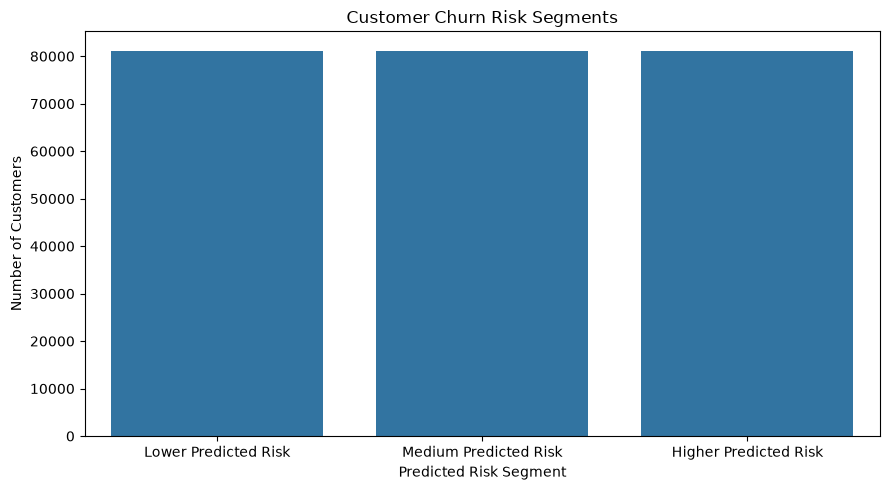

In [15]:
# ==================================================
# STEP 10.2 — RELATIVE CUSTOMER RISK
# ==================================================

# Divide customers into three groups based on
# their predicted churn probability.

df["risk_level"] = pd.qcut(
    df["churn_probability"],
    q=3,
    labels=[
        "Lower Predicted Risk",
        "Medium Predicted Risk",
        "Higher Predicted Risk"
    ],
    duplicates="drop"
)

print("\nRisk Distribution:")
print(df["risk_level"].value_counts().sort_index())

print("\nRisk Distribution (%):")
print(
    df["risk_level"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# --------------------------------------------------
# Save risk scores
# --------------------------------------------------

risk_columns = [
    "customer_id",
    "telecom_partner",
    "gender",
    "age",
    "state",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used",
    "churn_probability",
    "risk_level"
]

df[risk_columns].to_csv(
    "customer_churn_risk_scores.csv",
    index=False
)

# --------------------------------------------------
# Visualization
# --------------------------------------------------

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="risk_level",
    order=[
        "Lower Predicted Risk",
        "Medium Predicted Risk",
        "Higher Predicted Risk"
    ]
)

plt.title("Customer Churn Risk Segments")
plt.xlabel("Predicted Risk Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [16]:
# ==================================================
# STEP 11 — SQL ANALYSIS
# ==================================================

import sqlite3

print("\n" + "=" * 60)
print("SQL ANALYSIS")
print("=" * 60)

# --------------------------------------------------
# 1. Create SQLite database connection
# --------------------------------------------------

connection = sqlite3.connect("customer_churn.db")

# --------------------------------------------------
# 2. Prepare DataFrame for SQLite
# --------------------------------------------------

# Make a copy so the original df is not changed
sql_df = df.copy()

# These columns were created using pd.qcut()
# and contain pandas Interval objects.
# SQLite cannot store Interval objects.
sql_df = sql_df.drop(
    columns=[
        "calls_group",
        "data_usage_group"
    ],
    errors="ignore"
)

# Convert risk_level from pandas category to text
if "risk_level" in sql_df.columns:
    sql_df["risk_level"] = sql_df["risk_level"].astype(str)

# Convert date to text so SQLite can store it safely
if "date_of_registration" in sql_df.columns:
    sql_df["date_of_registration"] = (
        sql_df["date_of_registration"]
        .dt.strftime("%Y-%m-%d")
    )

# --------------------------------------------------
# 3. Load data into SQLite
# --------------------------------------------------

sql_df.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)

print("\nCustomer data loaded into SQLite successfully.")

# --------------------------------------------------
# QUERY 1 — Overall KPIs
# --------------------------------------------------

query1 = """
SELECT
    COUNT(*) AS total_customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate
FROM customers;
"""

result1 = pd.read_sql_query(
    query1,
    connection
)

print("\n" + "-" * 50)
print("1. OVERALL KPIs")
print("-" * 50)

print(result1.to_string(index=False))

# --------------------------------------------------
# QUERY 2 — Churn by telecom partner
# --------------------------------------------------

query2 = """
SELECT
    telecom_partner,
    COUNT(*) AS customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY telecom_partner
ORDER BY churn_rate DESC;
"""

result2 = pd.read_sql_query(
    query2,
    connection
)

print("\n" + "-" * 50)
print("2. CHURN BY TELECOM PARTNER")
print("-" * 50)

print(result2.to_string(index=False))

# --------------------------------------------------
# QUERY 3 — Churn by gender
# --------------------------------------------------

query3 = """
SELECT
    gender,
    COUNT(*) AS customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY gender
ORDER BY churn_rate DESC;
"""

result3 = pd.read_sql_query(
    query3,
    connection
)

print("\n" + "-" * 50)
print("3. CHURN BY GENDER")
print("-" * 50)

print(result3.to_string(index=False))

# --------------------------------------------------
# QUERY 4 — Churn by state
# --------------------------------------------------

query4 = """
SELECT
    state,
    COUNT(*) AS customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY state
HAVING COUNT(*) >= 100
ORDER BY churn_rate DESC
LIMIT 10;
"""

result4 = pd.read_sql_query(
    query4,
    connection
)

print("\n" + "-" * 50)
print("4. TOP 10 STATES BY OBSERVED CHURN RATE")
print("-" * 50)

print(result4.to_string(index=False))

# --------------------------------------------------
# QUERY 5 — Usage comparison
# --------------------------------------------------

query5 = """
SELECT
    churn,
    COUNT(*) AS customers,
    ROUND(AVG(calls_made), 2) AS avg_calls,
    ROUND(AVG(sms_sent), 2) AS avg_sms,
    ROUND(AVG(data_used), 2) AS avg_data_used
FROM customers
GROUP BY churn
ORDER BY churn;
"""

result5 = pd.read_sql_query(
    query5,
    connection
)

print("\n" + "-" * 50)
print("5. USAGE BY CHURN STATUS")
print("-" * 50)

print(result5.to_string(index=False))

# --------------------------------------------------
# QUERY 6 — Predicted risk segments
# --------------------------------------------------

query6 = """
SELECT
    risk_level,
    COUNT(*) AS customers,
    ROUND(AVG(churn_probability), 4)
        AS avg_predicted_probability
FROM customers
GROUP BY risk_level
ORDER BY avg_predicted_probability;
"""

result6 = pd.read_sql_query(
    query6,
    connection
)

print("\n" + "-" * 50)
print("6. PREDICTED RISK SEGMENTS")
print("-" * 50)

print(result6.to_string(index=False))

# --------------------------------------------------
# 4. Save SQL results as CSV files
# --------------------------------------------------

result1.to_csv(
    "sql_overall_kpis.csv",
    index=False
)

result2.to_csv(
    "sql_partner_churn.csv",
    index=False
)

result3.to_csv(
    "sql_gender_churn.csv",
    index=False
)

result4.to_csv(
    "sql_state_churn.csv",
    index=False
)

result5.to_csv(
    "sql_usage_churn.csv",
    index=False
)

result6.to_csv(
    "sql_risk_segments.csv",
    index=False
)

# --------------------------------------------------
# 5. Close database connection
# --------------------------------------------------

connection.close()

print("\n" + "=" * 60)
print("SQL ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)


SQL ANALYSIS

Customer data loaded into SQLite successfully.

--------------------------------------------------
1. OVERALL KPIs
--------------------------------------------------
 total_customers  churned_customers  churn_rate
          243553              48827       20.05

--------------------------------------------------
2. CHURN BY TELECOM PARTNER
--------------------------------------------------
telecom_partner  customers  churned_customers  churn_rate
         Airtel      60905              12404       20.37
   Reliance Jio      61123              12234       20.02
       Vodafone      60802              12129       19.95
           BSNL      60723              12060       19.86

--------------------------------------------------
3. CHURN BY GENDER
--------------------------------------------------
gender  customers  churned_customers  churn_rate
     F      97576              19805       20.30
     M     145977              29022       19.88

--------------------------------